### identify the best-tuned cases, plot 3D tuning results

In [1]:
%matplotlib inline
import time
import numpy as np
import xesmf as xe
import xarray as xr
import cmocean as cm
import cartopy.crs as ccrs
import matplotlib.ticker
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import matplotlib.gridspec as gridspec

import os
import h5py
import scipy.io
from scipy.io import loadmat

#### Now read the newly saved mat and plot 3D parameter space and 2D maps!

In [2]:
res=0.5
fiM2_synbath = loadmat("/g/data/nm03/lxy581/matlab_model/data/combined_res%.2f_M2_3D_synbath.mat"%res)
print("/g/data/nm03/lxy581/matlab_model/data/combined_res%.2f_M2_3D_synbath.mat"%res)
# print(list(fiM2_synbath.keys()))   # list variables in the .mat file

# Example: read a dataset
RMSE   = fiM2_synbath['RMSE66'][:]*100 # wd, op, cd 
PE_net = fiM2_synbath['PE_net'][:]
Fcoast = fiM2_synbath['Fcoast'][:]
Fwave  = fiM2_synbath['Fwave'][:]
En_err = fiM2_synbath['En_err'][:]
total  = fiM2_synbath['total'][:]
parti  = fiM2_synbath['frac'][:]

k0array = np.squeeze(fiM2_synbath['k0array'][:])
wdarray = np.squeeze(fiM2_synbath['wdarray'][:])
oparray = np.squeeze(fiM2_synbath['oparray'][:])
lon = np.squeeze(fiM2_synbath['lon_out'][:])
lat = np.squeeze(fiM2_synbath['lat_out'][:])

print(RMSE.shape, PE_net.shape, k0array.shape, wdarray.shape)

/g/data/nm03/lxy581/matlab_model/data/combined_res0.50_M2_3D_synbath.mat
(41, 41, 41) (41, 41, 41) (41,) (41,)


In [3]:
# find minimum RMSE in open ocean (>1000m)
m_val = np.nanmin(RMSE)                 # global min
linearIndex = np.nanargmin(RMSE)        # linear index
kk, jj, ii = np.unravel_index(linearIndex, RMSE.shape)  # convert to subscripts
print(kk,jj,ii)

wd_scal = wdarray[ii]
op_scal = oparray[jj]
cd_scal = k0array[kk] * np.sqrt(2000)

print(f"OLD: cd={cd_scal:.4f}, op={op_scal:.2f}, wd={wd_scal:.2f}; "
      f"En_ERR: {En_err[kk,jj,ii]:.2e}; "
      f"RMSE: {RMSE[kk,jj,ii]:.2f} cm; "
      f"EF: bot={Fcoast[kk,jj,ii]:.2f}, wave={Fwave[kk,jj,ii]:.2f} TW, total={total[kk,jj,ii]:.2f} TW, frac={parti[kk,jj,ii]:.2f}"
      )

5 19 19
OLD: cd=0.0010, op=-0.25, wd=4.75; En_ERR: 3.28e-02; RMSE: 6.14 cm; EF: bot=1.93, wave=1.15 TW, total=3.08 TW, frac=0.37


#### without spring force

In [4]:
# find minimum RMSE in open ocean (>1000m)
RMSE_wd = RMSE[:,0,:]
m_val = np.nanmin(RMSE_wd)                 # global min
linearIndex = np.nanargmin(RMSE_wd)        # linear index
kk_wd, ii_wd = np.unravel_index(linearIndex, RMSE_wd.shape)  # convert to subscripts
print(kk_wd,ii_wd)

wd_scal = wdarray[ii_wd]
op_scal = oparray[0]
cd_scal = k0array[kk_wd] * np.sqrt(2000)

print(f"OLD: cd={cd_scal:.4f}, op={op_scal:.2f}, wd={wd_scal:.2f}; "
      f"En_ERR: {En_err[kk_wd,0,ii_wd]:.2e}; "
      f"RMSE: {RMSE[kk_wd,0,ii_wd]:.2f} cm; "
      f"EF: bot={Fcoast[kk_wd,0,ii_wd]:.2f}, wave={Fwave[kk_wd,0,ii_wd]:.2f} TW, total={total[kk_wd,0,ii_wd]:.2f} TW, frac={parti[kk_wd,0,ii_wd]:.2f}"
      )

40 12
OLD: cd=0.0080, op=-5.00, wd=3.00; En_ERR: 9.44e-02; RMSE: 9.47 cm; EF: bot=2.67, wave=0.76 TW, total=3.43 TW, frac=0.22


In [5]:
# find minimum energy error
m_val_en = np.nanmin(En_err)
linearIndex_en = np.nanargmin(En_err)
kk_en, jj_en, ii_en = np.unravel_index(linearIndex_en, En_err.shape)
print(kk_en, jj_en, ii_en)

wd_scal_en = wdarray[ii_en]
op_scal_en = oparray[jj_en]
cd_scal_en = k0array[kk_en] * np.sqrt(2000)

print(f"NEW: cd={cd_scal_en:.4f}, op={op_scal_en:.2f}, wd={wd_scal_en:.2f}; "
      f"En_ERR: {En_err[kk_en,jj_en,ii_en]:.2e}; "
      f"RMSE: {RMSE[kk_en,jj_en,ii_en]:.2f} cm; "
      f"EF: bot={Fcoast[kk_en,jj_en,ii_en]:.2f}, wave={Fwave[kk_en,jj_en,ii_en]:.2f} TW, total={total[kk_en,jj_en,ii_en]:.2f} TW, frac={parti[kk_en,jj_en,ii_en]:.2f}"
      )

3 34 14
NEW: cd=0.0006, op=3.50, wd=3.50; En_ERR: 5.98e-05; RMSE: 9.16 cm; EF: bot=1.65, wave=0.79 TW, total=2.44 TW, frac=0.32


#### without spring force

In [6]:
imid, jmid, kmid = ii_en, jj_en, kk_en
cd_best = k0array[kmid]
wd_scal_best = wdarray[imid]
op_scal_best = oparray[jmid]
print(cd_best * np.sqrt(2000)) # 1.78885e-05
print(wd_scal_best) # 2.25
print(op_scal_best) # 7

0.0006000000000000001
3.5
3.5


In [7]:
imid_rmse, jmid_rmse, kmid_rmse = ii, jj, kk
cd_rmse = k0array[kmid_rmse]
wd_scal_rmse = wdarray[imid_rmse]
op_scal_rmse = oparray[jmid_rmse]
print(cd_rmse * np.sqrt(2000)) # 6.03738e-05
print(wd_scal_rmse) # 2.25
print(op_scal_rmse) # 4.75

0.001
4.75
-0.25


In [8]:
# X, Y, Z = np.meshgrid(wd_scal, op_scal, cd, indexing='ij')
nx, ny, nz = RMSE.shape
x = np.arange(nx)
y = np.arange(ny)
z = np.arange(nz)
X, Y, Z = np.meshgrid(x, y, z, indexing="xy")

#### Plot 3D tuning

14 34 3
Current view: 30 -60


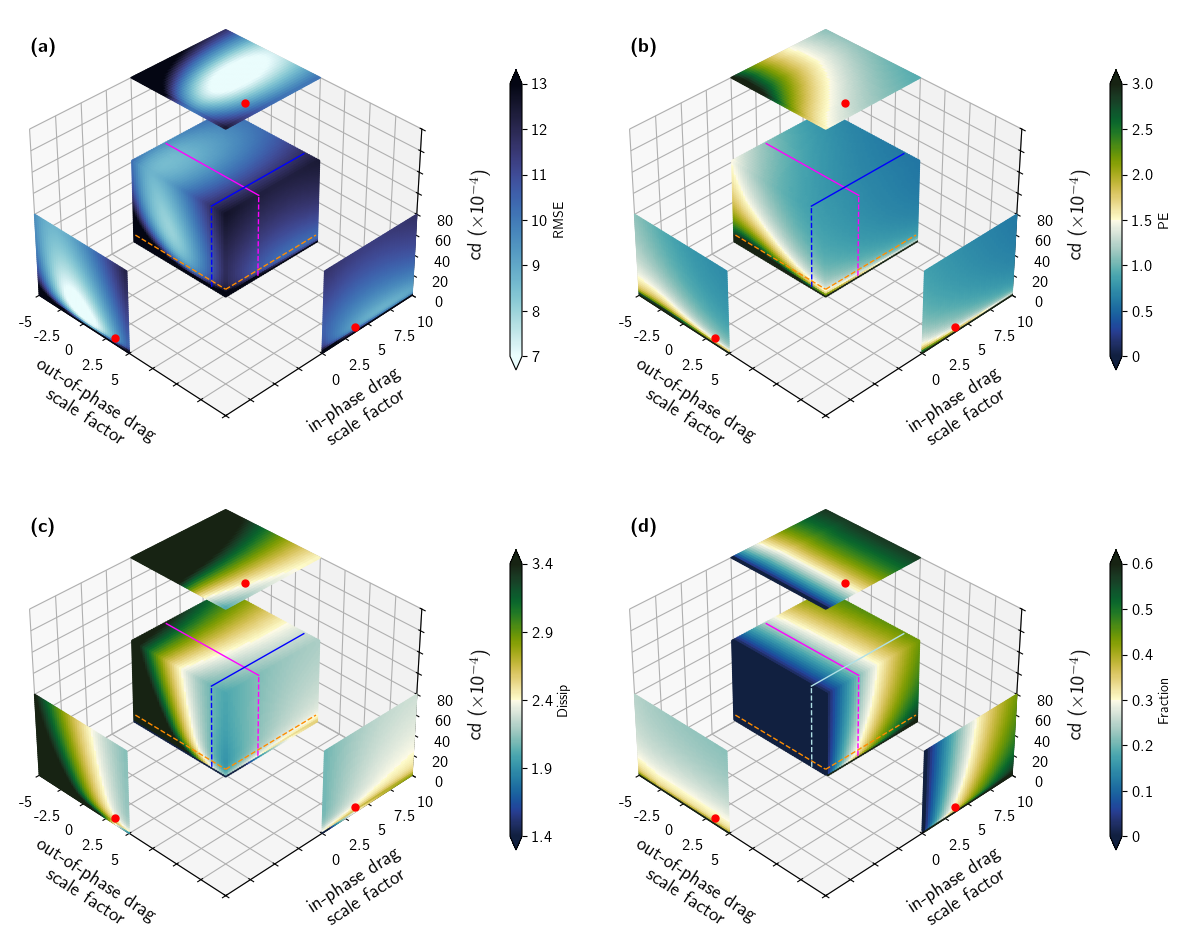

In [9]:
# Enable LaTeX text rendering
plt.rc('text', usetex=True)

var1 = np.transpose(RMSE)
var2 = np.transpose(PE_net)
var3 = np.transpose(total)
var4 = np.transpose(parti)

# rmse
rmse_tick_locs = np.array([7,8,9,10,11,12,13])
rmse_tick_labels = np.array(["7","8","9","10","11","12","13"])

# PE
pe_tick_locs = np.array([0,0.5,1.0,1.5,2.0,2.5,3.0])
pe_tick_labels = np.array(["0","0.5","1.0","1.5","2.0","2.5","3.0"])

# dissip
dissip_tick_locs = np.array([1.4,1.9,2.4,2.9,3.4])
dissip_tick_labels = np.array(["1.4","1.9","2.4","2.9","3.4"])

# fraction of wave drag dissip
parti_tick_locs = np.array([0,0.1,0.2,0.3,0.4,0.5,0.6])
parti_tick_labels = np.array(["0","0.1","0.2","0.3","0.4","0.5","0.6"])

fontsize=14
num11, num12 = 0.05,0.9
num21, num22 = 0.05,0.9
num31, num32 = 0.05,0.9
num41, num42 = 0.05,0.9

# imid, jmid, kmid = ii,jj,kk
imid, jmid, kmid = ii_en,jj_en,kk_en
print(imid,jmid,kmid)

fig = plt.figure(figsize=(20, 12))

# -----------------------------------------------------------
ax = fig.add_subplot(221, projection='3d')

# Get current view
current_elev = ax.elev
current_azim = ax.azim
print("Current view:", current_elev, current_azim)

# Set viewing angle
ax.view_init(elev=35, azim=-45)
# elev = elevation angle in degrees (0 = look from the side, 90 = look straight down).
# azim = azimuth angle in degrees (rotation around z-axis).
ax.tick_params(labelsize=12)
# --- 3D scatter (all points)

sc = ax.scatter(X, Y, Z, c=var1.flatten(), cmap=cm.cm.ice_r, alpha=1, s=5, vmin=7, vmax=13)

# Add colorbar
# fig.colorbar(sc, ax=ax, label="RMSE")
cbar_ax = fig.add_axes([0.42, 0.65, 0.006, 0.25])  # x, y, width, height
cbar = fig.colorbar(sc, cax=cbar_ax, label="RMSE", extend="both")
cbar.ax.tick_params(labelsize=12)
cbar.locator   = matplotlib.ticker.FixedLocator(rmse_tick_locs)
cbar.formatter = matplotlib.ticker.FixedFormatter(rmse_tick_labels)

norm = sc.norm           
cmap = sc.cmap    

# --- Choose transect (e.g., middle in y-direction)
slice_xy = var1[:,:,Z[jmid, imid, kmid]]
colors_xy = cmap(norm(slice_xy))

slice_xz = var1[X[jmid, imid, kmid],:,:]
colors_xz = cmap(norm(slice_xz))

slice_yz = var1[:,Y[jmid, imid, kmid],:]
colors_yz = cmap(norm(slice_yz))

ax.plot_surface(X[:,:,kmid],Y[:,:,kmid],np.full_like(X[:,:,kmid],80),facecolors=colors_xy,shade=False,alpha=1,zorder=6)
ax.plot_surface(X[jmid,:,:],np.full_like(X[jmid,:,:],-40),Z[jmid,:,:],facecolors=colors_xz,shade=False,alpha=1,zorder=6)
ax.plot_surface(np.full_like(X[:,imid,:],80),Y[:,imid,:],Z[:,imid,:],facecolors=colors_yz,shade=False,alpha=1,zorder=6)

# mark z slice
ax.plot([Y.min(), Y.max()], [0, 0],
        [Z[jmid, imid, kmid], Z[jmid, imid, kmid]], color='darkorange', linestyle='--', linewidth=1, zorder=12)
ax.plot([40, 40], [X.min(), X.max()],
        [Z[jmid, imid, kmid], Z[jmid, imid, kmid]], color='darkorange', linestyle='--', linewidth=1, zorder=12)

# mark y slice
ax.plot([Y.min(), Y.max()], [X[jmid, imid, kmid], X[jmid, imid, kmid]],
        [40, 40], color='magenta', linestyle='-', linewidth=1, zorder=12)
ax.plot([40, 40], [X[jmid, imid, kmid], X[jmid, imid, kmid]],
        [Z.min(), Z.max()], color='magenta', linestyle='--', linewidth=1, zorder=12)

# mark x slice
ax.plot([Y[jmid, imid, kmid], Y[jmid, imid, kmid]], [X.min(), X.max()],
        [40, 40], color='blue', linestyle='-', linewidth=1, zorder=12)
ax.plot([Y[jmid, imid, kmid], Y[jmid, imid, kmid]], [0, 0],
        [Z.min(), Z.max()], color='blue', linestyle='--', linewidth=1, zorder=12)

# Plot as a single 3D point
ax.plot([Y[jmid, imid, kmid]], [X[jmid, imid, kmid]], [80], 'o', color='red', markersize=5, zorder=12)
ax.plot([Y[jmid, imid, kmid]], [-40], [Z[jmid, imid, kmid]], 'o', color='red', markersize=5, zorder=12)
ax.plot([80], [X[jmid, imid, kmid]], [Z[jmid, imid, kmid]], 'o', color='red', markersize=5, zorder=12)

ax.set_xlim(0,80)
ax.set_ylim(-40,40)
ax.set_zlim(0,80)
ax.set_xticks(np.arange(0,80+10,10))
ax.set_yticks(np.arange(-40,40+10,10))
ax.set_zticks(np.arange(0,80+10,10))
ax.set_xticklabels(['-5','-2.5','0','2.5','5','','','',''])
ax.set_yticklabels(['','','','','0','2.5','5','7.5','10'])
ax.set_zticklabels(['0','20','40','60','80','','','',''])
ax.set_ylabel("in-phase drag\nscale factor",labelpad=10,fontsize=fontsize)
ax.set_xlabel("out-of-phase drag\nscale factor",labelpad=10,fontsize=fontsize)
ax.set_zlabel(r"cd ($\times$10$^{-4}$)",fontsize=fontsize)
ax.set_position([0.1, 0.6,0.35,0.35])
ax.text2D(num11, num12, r'\textbf{(a)}', transform=ax.transAxes, fontsize=fontsize)

# -----------------------------------------------------------
ax2 = fig.add_subplot(222, projection='3d')

# Set viewing angle
ax2.view_init(elev=35, azim=-45)
ax2.tick_params(labelsize=12)

sc2 = ax2.scatter(X, Y, Z, c=var2.flatten(), cmap=cm.cm.delta, alpha=1, s=5, vmin=0, vmax=3)

cbar_ax2 = fig.add_axes([0.72, 0.65, 0.006, 0.25])  # x, y, width, height
cbar2 = fig.colorbar(sc2, cax=cbar_ax2, label="PE", extend="both")
cbar2.ax.tick_params(labelsize=12)
cbar2.locator   = matplotlib.ticker.FixedLocator(pe_tick_locs)
cbar2.formatter = matplotlib.ticker.FixedFormatter(pe_tick_labels)

norm2 = sc2.norm           
cmap2 = sc2.cmap    

# --- Choose transect (e.g., middle in y-direction)
slice_xy2 = var2[:,:,Z[jmid, imid, kmid]]
colors_xy2 = cmap2(norm2(slice_xy2))

slice_xz2 = var2[X[jmid, imid, kmid],:,:]
colors_xz2 = cmap2(norm2(slice_xz2))

slice_yz2 = var2[:,Y[jmid, imid, kmid],:]
colors_yz2 = cmap2(norm2(slice_yz2))

ax2.plot_surface(X[:,:,kmid],Y[:,:,kmid],np.full_like(X[:,:,kmid],80),facecolors=colors_xy2,shade=False,alpha=1)
ax2.plot_surface(X[jmid,:,:],np.full_like(X[jmid,:,:],-40),Z[jmid,:,:],facecolors=colors_xz2,shade=False,alpha=1)
ax2.plot_surface(np.full_like(X[:,imid,:],80),Y[:,imid,:],Z[:,imid,:],facecolors=colors_yz2,shade=False,alpha=1)

# mark z slice
ax2.plot([Y.min(), Y.max()], [0, 0],
        [Z[jmid, imid, kmid], Z[jmid, imid, kmid]], color='darkorange', linestyle='--', linewidth=1, zorder=12)
ax2.plot([40, 40], [X.min(), X.max()],
        [Z[jmid, imid, kmid], Z[jmid, imid, kmid]], color='darkorange', linestyle='--', linewidth=1, zorder=12)

# mark y slice
ax2.plot([Y.min(), Y.max()], [X[jmid, imid, kmid], X[jmid, imid, kmid]],
        [40, 40], color='magenta', linestyle='-', linewidth=1, zorder=12)
ax2.plot([40, 40], [X[jmid, imid, kmid], X[jmid, imid, kmid]],
        [Z.min(), Z.max()], color='magenta', linestyle='--', linewidth=1, zorder=12)

# mark x slice
ax2.plot([Y[jmid, imid, kmid], Y[jmid, imid, kmid]], [X.min(), X.max()],
        [40, 40], color='blue', linestyle='-', linewidth=1, zorder=12)
ax2.plot([Y[jmid, imid, kmid], Y[jmid, imid, kmid]], [0, 0],
        [Z.min(), Z.max()], color='blue', linestyle='--', linewidth=1, zorder=12)

# Plot as a single 3D point
ax2.plot([Y[jmid, imid, kmid]], [X[jmid, imid, kmid]], [80], 'o', color='red', markersize=5, zorder=12)
ax2.plot([Y[jmid, imid, kmid]], [-40], [Z[jmid, imid, kmid]], 'o', color='red', markersize=5, zorder=12)
ax2.plot([80], [X[jmid, imid, kmid]], [Z[jmid, imid, kmid]], 'o', color='red', markersize=5, zorder=12)

ax2.set_xlim(0,80)
ax2.set_ylim(-40,40)
ax2.set_zlim(0,80)
ax2.set_xticks(np.arange(0,80+10,10))
ax2.set_yticks(np.arange(-40,40+10,10))
ax2.set_zticks(np.arange(0,80+10,10))
ax2.set_xticklabels(['-5','-2.5','0','2.5','5','','','',''])
ax2.set_yticklabels(['','','','','0','2.5','5','7.5','10'])
ax2.set_zticklabels(['0','20','40','60','80','','','',''])
ax2.set_ylabel("in-phase drag\nscale factor",labelpad=10,fontsize=fontsize)
ax2.set_xlabel("out-of-phase drag\nscale factor",labelpad=10,fontsize=fontsize)
ax2.set_zlabel(r"cd ($\times$10$^{-4}$)",fontsize=fontsize)
ax2.set_position([0.4, 0.6,0.35,0.35])
ax2.text2D(num21, num22, r'\textbf{(b)}', transform=ax2.transAxes, fontsize=fontsize)

# -----------------------------------------------------------
ax3 = fig.add_subplot(223, projection='3d')

# Set viewing angle
ax3.view_init(elev=35, azim=-45)
ax3.tick_params(labelsize=12)

sc3 = ax3.scatter(X, Y, Z, c=var3.flatten(), cmap=cm.cm.delta, alpha=1, s=5, vmin=1.4, vmax=3.4)

cbar_ax3 = fig.add_axes([0.42, 0.25, 0.006, 0.25])  # x, y, width, height
cbar3 = fig.colorbar(sc3, cax=cbar_ax3, label="Dissip", extend="both")
cbar3.ax.tick_params(labelsize=12)
cbar3.locator   = matplotlib.ticker.FixedLocator(dissip_tick_locs)
cbar3.formatter = matplotlib.ticker.FixedFormatter(dissip_tick_labels)

norm3 = sc3.norm           
cmap3 = sc3.cmap    

# --- Choose transect (e.g., middle in y-direction)
slice_xy3 = var3[:,:,Z[jmid, imid, kmid]]
colors_xy3 = cmap3(norm3(slice_xy3))

slice_xz3 = var3[X[jmid, imid, kmid],:,:]
colors_xz3 = cmap3(norm3(slice_xz3))

slice_yz3 = var3[:,Y[jmid, imid, kmid],:]
colors_yz3 = cmap3(norm3(slice_yz3))

ax3.plot_surface(X[:,:,kmid],Y[:,:,kmid],np.full_like(X[:,:,kmid],80),facecolors=colors_xy3,shade=False,alpha=1)
ax3.plot_surface(X[jmid,:,:],np.full_like(X[jmid,:,:],-40),Z[jmid,:,:],facecolors=colors_xz3,shade=False,alpha=1)
ax3.plot_surface(np.full_like(X[:,imid,:],80),Y[:,imid,:],Z[:,imid,:],facecolors=colors_yz3,shade=False,alpha=1)

# mark z slice
ax3.plot([Y.min(), Y.max()], [0, 0],
        [Z[jmid, imid, kmid], Z[jmid, imid, kmid]], color='darkorange', linestyle='--', linewidth=1, zorder=12)
ax3.plot([40, 40], [X.min(), X.max()],
        [Z[jmid, imid, kmid], Z[jmid, imid, kmid]], color='darkorange', linestyle='--', linewidth=1, zorder=12)

# mark y slice
ax3.plot([Y.min(), Y.max()], [X[jmid, imid, kmid], X[jmid, imid, kmid]],
        [40, 40], color='magenta', linestyle='-', linewidth=1, zorder=12)
ax3.plot([40, 40], [X[jmid, imid, kmid], X[jmid, imid, kmid]],
        [Z.min(), Z.max()], color='magenta', linestyle='--', linewidth=1, zorder=12)

# mark x slice
ax3.plot([Y[jmid, imid, kmid], Y[jmid, imid, kmid]], [X.min(), X.max()],
        [40, 40], color='blue', linestyle='-', linewidth=1, zorder=12)
ax3.plot([Y[jmid, imid, kmid], Y[jmid, imid, kmid]], [0, 0],
        [Z.min(), Z.max()], color='blue', linestyle='--', linewidth=1, zorder=12)


# Plot as a single 3D point
ax3.plot([Y[jmid, imid, kmid]], [X[jmid, imid, kmid]], [80], 'o', color='red', markersize=5, zorder=12)
ax3.plot([Y[jmid, imid, kmid]], [-40], [Z[jmid, imid, kmid]], 'o', color='red', markersize=5, zorder=12)
ax3.plot([80], [X[jmid, imid, kmid]], [Z[jmid, imid, kmid]], 'o', color='red', markersize=5, zorder=12)

ax3.set_xlim(0,80)
ax3.set_ylim(-40,40)
ax3.set_zlim(0,80)
ax3.set_xticks(np.arange(0,80+10,10))
ax3.set_yticks(np.arange(-40,40+10,10))
ax3.set_zticks(np.arange(0,80+10,10))
ax3.set_xticklabels(['-5','-2.5','0','2.5','5','','','',''])
ax3.set_yticklabels(['','','','','0','2.5','5','7.5','10'])
ax3.set_zticklabels(['0','20','40','60','80','','','',''])
ax3.set_ylabel("in-phase drag\nscale factor",labelpad=10,fontsize=fontsize)
ax3.set_xlabel("out-of-phase drag\nscale factor",labelpad=10,fontsize=fontsize)
ax3.set_zlabel(r"cd ($\times$10$^{-4}$)",fontsize=fontsize)
ax3.set_position([0.1,0.2,0.35,0.35])
ax3.text2D(num31, num32, r'\textbf{(c)}', transform=ax3.transAxes, fontsize=fontsize)


# -----------------------------------------------------------
ax4 = fig.add_subplot(223, projection='3d')

# Set viewing angle
ax4.view_init(elev=35, azim=-45)
ax4.tick_params(labelsize=12)

sc4 = ax4.scatter(X, Y, Z, c=var4.flatten(), cmap=cm.cm.delta, alpha=1, s=5, vmin=0, vmax=0.6)

cbar_ax4 = fig.add_axes([0.72, 0.25, 0.006, 0.25])  # x, y, width, height
cbar4 = fig.colorbar(sc4, cax=cbar_ax4, label="Fraction", extend="both")
cbar4.ax.tick_params(labelsize=12)
cbar4.locator   = matplotlib.ticker.FixedLocator(parti_tick_locs)
cbar4.formatter = matplotlib.ticker.FixedFormatter(parti_tick_labels)

norm4 = sc4.norm           
cmap4 = sc4.cmap    

# --- Choose transect (e.g., middle in y-direction)
slice_xy4 = var4[:,:,Z[jmid, imid, kmid]]
colors_xy4 = cmap4(norm4(slice_xy4))

slice_xz4 = var4[X[jmid, imid, kmid],:,:]
colors_xz4 = cmap4(norm4(slice_xz4))

slice_yz4 = var4[:,Y[jmid, imid, kmid],:]
colors_yz4 = cmap4(norm4(slice_yz4))

ax4.plot_surface(X[:,:,kmid],Y[:,:,kmid],np.full_like(X[:,:,kmid],80),facecolors=colors_xy4,shade=False,alpha=1)
ax4.plot_surface(X[jmid,:,:],np.full_like(X[jmid,:,:],-40),Z[jmid,:,:],facecolors=colors_xz4,shade=False,alpha=1)
ax4.plot_surface(np.full_like(X[:,imid,:],80),Y[:,imid,:],Z[:,imid,:],facecolors=colors_yz4,shade=False,alpha=1)

# mark z slice
ax4.plot([Y.min(), Y.max()], [0, 0],
        [Z[jmid, imid, kmid], Z[jmid, imid, kmid]], color='darkorange', linestyle='--', linewidth=1, zorder=12)
ax4.plot([40, 40], [X.min(), X.max()],
        [Z[jmid, imid, kmid], Z[jmid, imid, kmid]], color='darkorange', linestyle='--', linewidth=1, zorder=12)

# mark y slice
ax4.plot([Y.min(), Y.max()], [X[jmid, imid, kmid], X[jmid, imid, kmid]],
        [40, 40], color='magenta', linestyle='-', linewidth=1, zorder=12)
ax4.plot([40, 40], [X[jmid, imid, kmid], X[jmid, imid, kmid]],
        [Z.min(), Z.max()], color='magenta', linestyle='--', linewidth=1, zorder=12)

# mark x slice
ax4.plot([Y[jmid, imid, kmid], Y[jmid, imid, kmid]], [X.min(), X.max()],
        [40, 40], color='powderblue', linestyle='-', linewidth=1, zorder=12)
ax4.plot([Y[jmid, imid, kmid], Y[jmid, imid, kmid]], [0, 0],
        [Z.min(), Z.max()], color='powderblue', linestyle='--', linewidth=1, zorder=12)


# Plot as a single 3D point
ax4.plot([Y[jmid, imid, kmid]], [X[jmid, imid, kmid]], [80], 'o', color='red', markersize=5, zorder=12)
ax4.plot([Y[jmid, imid, kmid]], [-40], [Z[jmid, imid, kmid]], 'o', color='red', markersize=5, zorder=12)
ax4.plot([80], [X[jmid, imid, kmid]], [Z[jmid, imid, kmid]], 'o', color='red', markersize=5, zorder=12)

ax4.set_xlim(0,80)
ax4.set_ylim(-40,40)
ax4.set_zlim(0,80)
ax4.set_xticks(np.arange(0,80+10,10))
ax4.set_yticks(np.arange(-40,40+10,10))
ax4.set_zticks(np.arange(0,80+10,10))
ax4.set_xticklabels(['-5','-2.5','0','2.5','5','','','',''])
ax4.set_yticklabels(['','','','','0','2.5','5','7.5','10'])
ax4.set_zticklabels(['0','20','40','60','80','','','',''])
ax4.set_ylabel("in-phase drag\nscale factor",labelpad=10,fontsize=fontsize)
ax4.set_xlabel("out-of-phase drag\nscale factor",labelpad=10,fontsize=fontsize)
ax4.set_zlabel(r"cd ($\times$10$^{-4}$)",fontsize=fontsize)
ax4.set_position([0.4,0.2,0.35,0.35])
ax4.text2D(num41, num42, r'\textbf{(d)}', transform=ax4.transAxes, fontsize=fontsize)

plt.savefig('/g/data/nm03/lxy581/matlab_model/figures/RMSE_0.5deg_M2_3D_2000m_new_best_synbath.png', dpi=300, bbox_inches='tight')

In [10]:
print(imid,jmid,kmid)
print(X[jmid, imid, kmid])
print(Y[jmid, imid, kmid])
print(Z[jmid, imid, kmid])

14 34 3
14
34
3


#### Plot spatial maps of eta, wave & coast dissipation

In [11]:
eta_old = fiM2_synbath['eta_2D_old'][:]
eta_new = fiM2_synbath['eta_2D_new'][:]
Fcoast_old = fiM2_synbath['Fcoast_2D_old'][:]*1e+3
Fcoast_new = fiM2_synbath['Fcoast_2D_new'][:]*1e+3
Fwave_old = fiM2_synbath['Fwave_2D_old'][:]*1e+3
Fwave_new = fiM2_synbath['Fwave_2D_new'][:]*1e+3
print(np.nanmin(eta_old),np.nanmax(eta_old))
print(np.nanmin(eta_new),np.nanmax(eta_new))
print(np.nanmin(Fcoast_old),np.nanmax(Fcoast_old))
print(np.nanmin(Fcoast_new),np.nanmax(Fcoast_new))
print(np.nanmin(Fwave_old),np.nanmax(Fwave_old))
print(np.nanmin(Fwave_new),np.nanmax(Fwave_new))

0.0 2.307573473274152
0.0 3.0505919241049524
0.0 2190.689956732461
0.0 2073.993108248406
0.0 720.6503512023925
0.0 807.5837636211128


In [12]:
lat_shift = lat
lon_shift = np.full((lon.size),np.nan)

eta_old_shift = np.full((eta_old.shape),np.nan)
eta_new_shift = np.full((eta_old.shape),np.nan)
Fcoast_old_shift = np.full((eta_old.shape),np.nan)
Fcoast_new_shift = np.full((eta_old.shape),np.nan)
Fwave_old_shift = np.full((eta_old.shape),np.nan)
Fwave_new_shift = np.full((eta_old.shape),np.nan)

ind = np.argmax(lon > 80)
print(ind)
print(lon[ind])

lon_shift[0:-ind] = lon[ind:]-360
lon_shift[-ind:] = lon[0:ind]

eta_old_shift[0:-ind,:] = eta_old[ind:,:]
eta_old_shift[-ind:,:] = eta_old[0:ind,:]

eta_new_shift[0:-ind,:] = eta_new[ind:,:]
eta_new_shift[-ind:,:] = eta_new[0:ind,:]

Fcoast_old_shift[0:-ind,:] = Fcoast_old[ind:,:]
Fcoast_old_shift[-ind:,:] = Fcoast_old[0:ind,:]

Fcoast_new_shift[0:-ind,:] = Fcoast_new[ind:,:]
Fcoast_new_shift[-ind:,:] = Fcoast_new[0:ind,:]

Fwave_old_shift[0:-ind,:] = Fwave_old[ind:,:]
Fwave_old_shift[-ind:,:] = Fwave_old[0:ind,:]

Fwave_new_shift[0:-ind,:] = Fwave_new[ind:,:]
Fwave_new_shift[-ind:,:] = Fwave_new[0:ind,:]

160
80.25


In [13]:
print(eta_old_shift.shape)

(720, 360)


In [14]:
topog = loadmat("/g/data/nm03/lxy581/global_drag_coeff/sigma_SAH_M2_025deg_spring_2d_global.mat")
# print(list(topog.keys()))   # list variables in the .mat file

depth_z = np.transpose(topog['depth_out'][:])
geolat_t = np.squeeze(topog['lat_out'][:])
geolon_t = np.squeeze(topog['lon_out'][:])

LONT, LATT = np.meshgrid(geolon_t,geolat_t,indexing='ij')
print(depth_z.shape,LONT.shape)

# print(np.nanmin(depth_z),np.nanmax(depth_z))
depth_da = xr.Dataset(data_vars={'depth_xr': (('yh','xh'), depth_z),
                                }, 
                      coords={'lon': (('yh', 'xh'), LONT),
                              'lat': (('yh', 'xh'), LATT)})
land = xr.where(np.isnan(depth_da.depth_xr[:,:].rename('land')), 1, np.nan)

(1440, 720) (1440, 720)


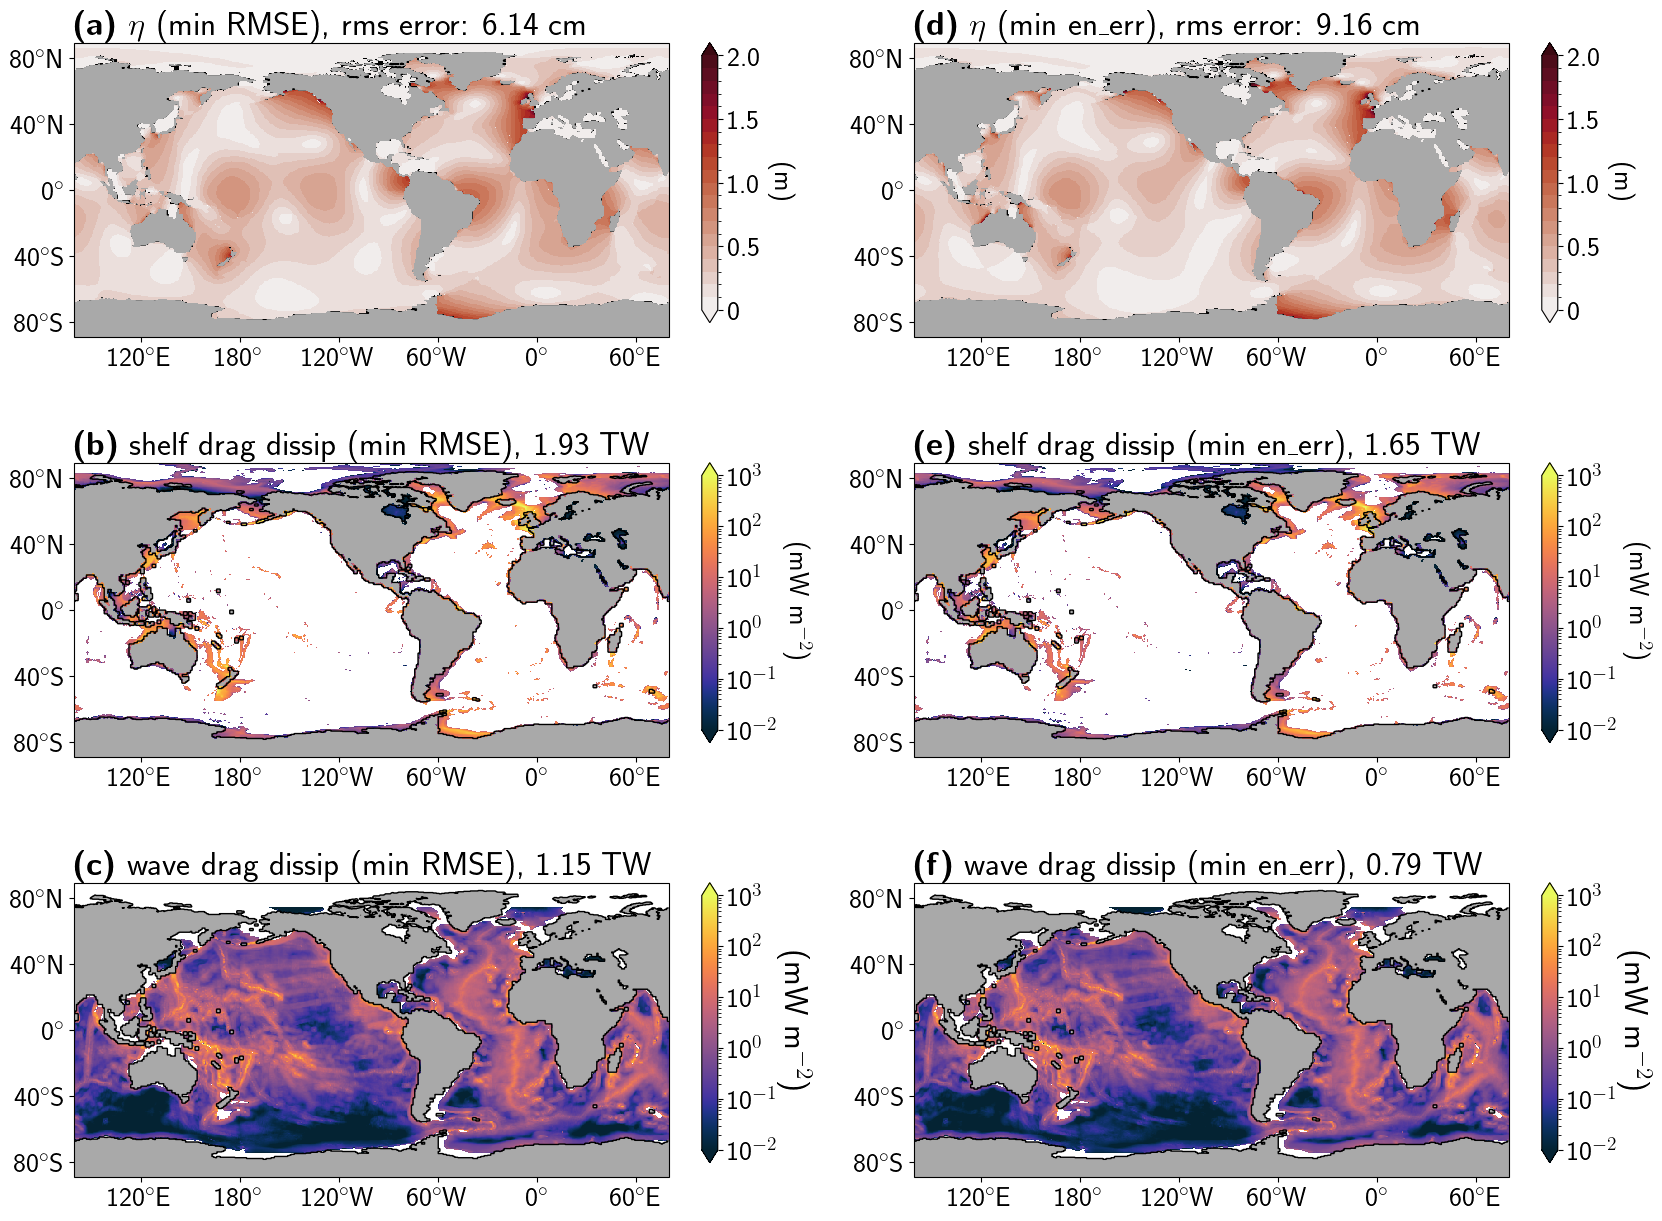

In [18]:
# Enable LaTeX text rendering
plt.rc('text', usetex=True)

varlist = ['eta_old_shift','Fcoast_old_shift','Fwave_old_shift',
           'eta_new_shift','Fcoast_new_shift','Fwave_new_shift']

# varlist = ['eta_old','Fcoast_old','Fwave_old',
#            'eta_new','Fcoast_new','Fwave_new']
title   = [r'\textbf{(a)} $\eta$ (min RMSE), rms error: %.2f cm'%RMSE[kk,jj,ii],
           r'\textbf{(b)} shelf drag dissip (min RMSE), %.2f TW'%Fcoast[kk,jj,ii], 
           r'\textbf{(c)} wave drag dissip (min RMSE), %.2f TW'%Fwave[kk,jj,ii],
           r'\textbf{(d)} $\eta$ (min en_err), rms error: %.2f cm'%RMSE[kk_en,jj_en,ii_en],
           r'\textbf{(e)} shelf drag dissip (min en_err), %.2f TW'%Fcoast[kk_en,jj_en,ii_en], 
           r'\textbf{(f)} wave drag dissip (min en_err), %.2f TW'%Fwave[kk_en,jj_en,ii_en]]

LON, LAT = np.meshgrid(lon,lat,indexing='ij')
LON_shift, LAT_shift = np.meshgrid(lon_shift,lat_shift,indexing='ij')

lons = ['LON_shift']*6
lats = ['LAT_shift']*6

# eta
e_tick_locs = np.arange(0,2.0+0.5,0.5)
e_tick_labels = np.array(["0","0.5","1.0","1.5","2.0"])

# dissip
d_tick_locs = np.array([1e-2,1e-1,1e+0,1e+1,1e+2,1e+3])
d_tick_labels = np.array(["10$^{-2}$","10$^{-1}$","10$^{0}$","10$^{1}$","10$^{2}$","10$^{3}$"])

fig = plt.figure(figsize=(20, 14))
axs = []

gridsubs = gridspec.GridSpec(3,2)
for I, gs in enumerate(gridsubs):
    axs.append(plt.subplot(gs))

for I, (ax, var) in enumerate(zip(axs, varlist)):

    for side in ['top','right','bottom','left']:
        ax.spines[side].set_visible(False)
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_facecolor('white')

    ax = plt.axes(projection=ccrs.Robinson(central_longitude=180))
    # Add model land mask
    land.plot.contourf(ax=ax, x='lon', y='lat', colors='darkgrey', add_colorbar=False)
    # Add model coastline
    land.fillna(0).plot.contour(ax=ax, x='lon', y='lat', colors='k', levels=[0, 1], add_colorbar=False, linewidths=1)
    plt.title('')

    cmap = cm.cm.thermal.copy()
    cmap.set_bad((0.0, 0.0, 0.0, 0.0))
    
    ax.get_xaxis().set_ticks([])
    ax.get_yaxis().set_ticks([])
    ax.set_title(title[I],fontsize=24,loc="left")
    ax.set_xticks(np.arange(-240,60+60,60))
    ax.set_xticklabels(['120$^{\circ}$E','180$^{\circ}$','120$^{\circ}$W','60$^{\circ}$W','0$^{\circ}$','60$^{\circ}$E'])
    ax.set_yticks(np.arange(-80,80+40,40))
    ax.set_yticklabels(['80$^{\circ}$S','40$^{\circ}$S','0$^{\circ}$','40$^{\circ}$N','80$^{\circ}$N'])
    ax.set_ylim(-89,89)
    ax.tick_params(labelsize=20)

    cmap = cm.cm.thermal

    if I==0:
        bounds = np.arange(0, 2.1, 0.1)
        norm = mcolors.BoundaryNorm(boundaries=bounds, ncolors=cm.cm.amp.N, extend='max')
        p1 = ax.pcolormesh(globals()[lons[I]], globals()[lats[I]], globals()[var], cmap=cm.cm.amp, norm=norm, zorder=2) # , vmin=0, vmax=2.5
        ax.set_xlabel('')
        ax.set_ylabel('')
        ax_cb = plt.axes([0.44, 0.71, 0.008, 0.2])
        cb1 = plt.colorbar(p1, cax=ax_cb, orientation='vertical', extend='both')
        cb1.ax.set_ylabel('(m)',fontsize=20,rotation=270,labelpad=25);
        cb1.ax.tick_params(labelsize=20)
        cb1.locator   = matplotlib.ticker.FixedLocator(e_tick_locs)
        cb1.formatter = matplotlib.ticker.FixedFormatter(e_tick_labels)
        ax.set_position([0.1,0.7,0.35,0.21])
        
    if I==1:
        p1 = ax.pcolormesh(globals()[lons[I]], globals()[lats[I]], globals()[var], cmap=cmap, norm=LogNorm(vmin=1e-2, vmax=1e+3))
        ax.set_xlabel('')
        ax.set_ylabel('')
        ax_cb = plt.axes([0.44, 0.41, 0.008, 0.2])
        cb1 = plt.colorbar(p1, cax=ax_cb, orientation='vertical', extend='both')
        cb1.ax.set_ylabel('(mW m$^{-2}$)',fontsize=20,rotation=270,labelpad=25);
        cb1.ax.tick_params(labelsize=20)
        cb1.locator   = matplotlib.ticker.FixedLocator(d_tick_locs)
        cb1.formatter = matplotlib.ticker.FixedFormatter(d_tick_labels)
        ax.set_position([0.1,0.4,0.35,0.21])

    if I==2:
        p1 = ax.pcolormesh(globals()[lons[I]], globals()[lats[I]], globals()[var], cmap=cmap, norm=LogNorm(vmin=1e-2, vmax=1e+3))
        ax.set_xlabel('')
        ax.set_ylabel('')
        ax_cb = plt.axes([0.44, 0.11, 0.008, 0.2])
        cb1 = plt.colorbar(p1, cax=ax_cb, orientation='vertical', extend='both')
        cb1.ax.set_ylabel('(mW m$^{-2}$)',fontsize=24,rotation=270,labelpad=25);
        cb1.ax.tick_params(labelsize=20)
        cb1.locator   = matplotlib.ticker.FixedLocator(d_tick_locs)
        cb1.formatter = matplotlib.ticker.FixedFormatter(d_tick_labels)
        ax.set_position([0.1,0.1,0.35,0.21])

    if I==3:
        # p1 = ax.pcolormesh(globals()[lons[I]], globals()[lats[I]], globals()[var], cmap=cm.cm.amp, vmin=0, vmax=2.5)
        bounds = np.arange(0, 2.1, 0.1)
        norm = mcolors.BoundaryNorm(boundaries=bounds, ncolors=cm.cm.amp.N, extend='max')
        p1 = ax.pcolormesh(globals()[lons[I]], globals()[lats[I]], globals()[var], cmap=cm.cm.amp, norm=norm, zorder=2) # , vmin=0, vmax=2.5
        ax.set_xlabel('')
        ax.set_ylabel('')
        ax_cb = plt.axes([0.86, 0.71, 0.008, 0.2])
        cb1 = plt.colorbar(p1, cax=ax_cb, orientation='vertical', extend='both')
        cb1.ax.set_ylabel('(m)',fontsize=20,rotation=270,labelpad=25);
        cb1.ax.tick_params(labelsize=20)
        cb1.locator   = matplotlib.ticker.FixedLocator(e_tick_locs)
        cb1.formatter = matplotlib.ticker.FixedFormatter(e_tick_labels)
        ax.set_position([0.52,0.7,0.35,0.21])

    if I==4:
        p1 = ax.pcolormesh(globals()[lons[I]], globals()[lats[I]], globals()[var], cmap=cmap, norm=LogNorm(vmin=1e-2, vmax=1e+3))
        ax.set_xlabel('')
        ax.set_ylabel('')
        ax_cb = plt.axes([0.86, 0.41, 0.008, 0.2])
        cb1 = plt.colorbar(p1, cax=ax_cb, orientation='vertical', extend='both')
        cb1.ax.set_ylabel('(mW m$^{-2}$)',fontsize=20,rotation=270,labelpad=25);
        cb1.ax.tick_params(labelsize=20)
        cb1.locator   = matplotlib.ticker.FixedLocator(d_tick_locs)
        cb1.formatter = matplotlib.ticker.FixedFormatter(d_tick_labels)
        ax.set_position([0.52,0.4,0.35,0.21])

    if I==5:
        p1 = ax.pcolormesh(globals()[lons[I]], globals()[lats[I]], globals()[var], cmap=cmap, norm=LogNorm(vmin=1e-2, vmax=1e+3))
        ax.set_xlabel('')
        ax.set_ylabel('')
        ax_cb = plt.axes([0.86, 0.11, 0.008, 0.2])
        cb2 = plt.colorbar(p1, cax=ax_cb, orientation='vertical', extend='both')
        cb2.ax.set_ylabel('(mW m$^{-2}$)',fontsize=24,rotation=270,labelpad=25);
        cb2.ax.tick_params(labelsize=20)
        cb2.locator   = matplotlib.ticker.FixedLocator(d_tick_locs)
        cb2.formatter = matplotlib.ticker.FixedFormatter(d_tick_labels)
        ax.set_position([0.52,0.1,0.35,0.21])

plt.savefig('/g/data/nm03/lxy581/matlab_model/figures/eta_dissip_0.5deg_M2_3D_2000m_old_new_best_synbath.png', dpi=300, bbox_inches='tight')